In [32]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import json

PROJECT_DIR   = "/content/drive/MyDrive/DLP2"
PROCESSED_DIR = os.path.join(PROJECT_DIR, "data/processed")
MODELS_DIR    = os.path.join(PROJECT_DIR, "models")
RESULTS_DIR   = os.path.join(PROJECT_DIR, "results")
FIGURES_DIR   = os.path.join(PROJECT_DIR, "figures")

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

X_train = np.load(os.path.join(PROCESSED_DIR, "X_train.npy"))
X_val   = np.load(os.path.join(PROCESSED_DIR, "X_val.npy"))
X_test  = np.load(os.path.join(PROCESSED_DIR, "X_test.npy"))
y_train = np.load(os.path.join(PROCESSED_DIR, "y_train.npy"))
y_val   = np.load(os.path.join(PROCESSED_DIR, "y_val.npy"))
y_test  = np.load(os.path.join(PROCESSED_DIR, "y_test.npy"))

with open(os.path.join(PROCESSED_DIR, "activity_labels.json"), "r") as f:
    activity_labels = json.load(f)

print("X_train:", X_train.shape)
print("X_val:",   X_val.shape)
print("X_test:",  X_test.shape)
print(activity_labels)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
X_train: (5881, 128, 9)
X_val: (1471, 128, 9)
X_test: (2947, 128, 9)
{'0': 'WALKING', '1': 'WALKING_UPSTAIRS', '2': 'WALKING_DOWNSTAIRS', '3': 'SITTING', '4': 'STANDING', '5': 'LAYING'}


In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix

TIME_STEPS   = X_train.shape[1]   # 128
NUM_CHANNELS = X_train.shape[2]   # 9
NUM_CLASSES  = len(activity_labels)
INPUT_SHAPE  = (TIME_STEPS, NUM_CHANNELS)

print("Input shape:", INPUT_SHAPE)
print("Number of classes:", NUM_CLASSES)
print("GPU:", tf.config.list_physical_devices('GPU'))

Input shape: (128, 9)
Number of classes: 6
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [34]:
ae_input = layers.Input(shape=INPUT_SHAPE)

# Encoder
enc = layers.Conv1D(64, 3, activation='relu', padding='same')(ae_input)
enc = layers.MaxPooling1D(2)(enc)
enc = layers.Conv1D(128, 3, activation='relu', padding='same')(enc)
encoded = layers.MaxPooling1D(2)(enc)   # (None, 32, 128)

# Decoder
dec = layers.Conv1D(128, 3, activation='relu', padding='same')(encoded)
dec = layers.UpSampling1D(2)(dec)
dec = layers.Conv1D(64, 3, activation='relu', padding='same')(dec)
dec = layers.UpSampling1D(2)(dec)
decoded = layers.Conv1D(NUM_CHANNELS, 3, activation='linear', padding='same')(dec)

autoencoder = keras.Model(ae_input, decoded, name="autoencoder")
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

ae_history = autoencoder.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=30,
    batch_size=64,
    callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=1
)

# Encoder'ı ayır ve dondur
encoder = keras.Model(ae_input, encoded, name="encoder")
for layer in encoder.layers:
    layer.trainable = False

print("Encoder output shape:", encoder.output_shape)

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 128, 64)        │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 64, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 32, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_2 (UpSampling1D)  │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 64, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_3 (UpSampling1D)  │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 128, 9)         │         1,737 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,153 (399.04 KB)

 Trainable params: 102,153 (399.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - loss: 0.1998 - val_loss: 0.0863
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0693 - val_loss: 0.0583
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0543 - val_loss: 0.0499
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0457 - val_loss: 0.0424
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0399 - val_loss: 0.0377
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0370 - val_loss: 0.0348
Epoch 7/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0366 - val_loss: 0.0374
Epoch 8/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0312 - val_loss: 0.0305
Epoch 9/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0300 - val_loss: 0.0292
Epoch 10/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0282 - val_loss: 0.0299
Epoch 11/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0273 - val_loss: 0.0316
Epoch 12/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0271 - val_l

In [35]:
def build_exp4_model(learning_rate=1e-3):
    """
    Exp 4: Encoder(frozen) → Conv1D → GRU → Dense → Output
    Exp 3'ten farkı: GRU eklendi
    Exp 5'ten farkı: BatchNorm ve Dropout YOK
    """
    enc_out = encoder.output   # (None, 32, 128)

    x = layers.Conv1D(64, 3, activation='relu', padding='same')(enc_out)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(128, 3, activation='relu', padding='same')(x)

    x = layers.GRU(64, return_sequences=False)(x)

    x = layers.Dense(64, activation='relu')(x)
    output = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = keras.Model(encoder.input, output, name="Exp4_AE_CNN_GRU")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model_exp4 = build_exp4_model()
model_exp4.summary()

Model: "Exp4_AE_CNN_GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 128, 64)        │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 64, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_12 (Conv1D)              │ (None, 32, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 16, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_13 (Conv1D)              │ (None, 16, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,638 (459.52 KB)

 Trainable params: 91,142 (356.02 KB)

 Non-trainable params: 26,496 (103.50 KB)

Epoch 1/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.7106 - loss: 0.7082 - val_accuracy: 0.8681 - val_loss: 0.3323
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8995 - loss: 0.2590 - val_accuracy: 0.9116 - val_loss: 0.2138
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9412 - loss: 0.1458 - val_accuracy: 0.9626 - val_loss: 0.1102
Epoch 4/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9461 - loss: 0.1261 - val_accuracy: 0.9585 - val_loss: 0.0986
Epoch 5/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9476 - loss: 0.1218 - val_accuracy: 0.9619 - val_loss: 0.1038
Epoch 6/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9543 - loss: 0.1059 - val_accuracy: 0.9619 - val_loss: 0.0966
Epoch 7/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9556 - loss: 0.1027 - val_accuracy: 0.9579 - val_loss: 0.0932
Epoch 8/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9553 - loss: 0.1058 - val_accuracy: 0.9633 - val_l

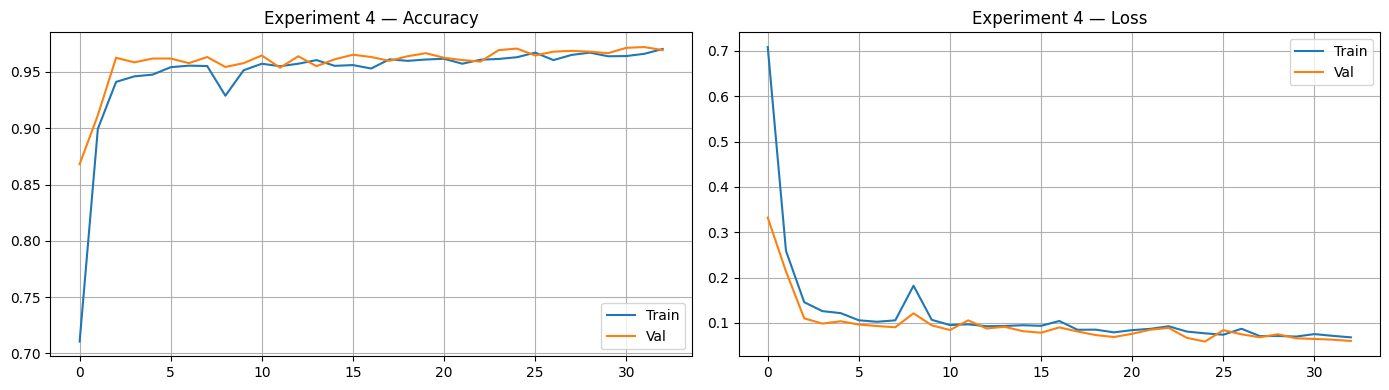

In [36]:
callbacks_exp4 = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=8, restore_best_weights=True
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(MODELS_DIR, "exp4_best.keras"),
        monitor='val_loss', save_best_only=True
    )
]

history_exp4 = model_exp4.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    callbacks=callbacks_exp4,
    verbose=1
)

# Training curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(history_exp4.history['accuracy'], label='Train')
ax1.plot(history_exp4.history['val_accuracy'], label='Val')
ax1.set_title('Experiment 4 — Accuracy')
ax1.legend(); ax1.grid(True)

ax2.plot(history_exp4.history['loss'], label='Train')
ax2.plot(history_exp4.history['val_loss'], label='Val')
ax2.set_title('Experiment 4 — Loss')
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "exp4_training_curves.png"), dpi=300, bbox_inches="tight")
plt.show()

Test Accuracy: 0.9196
Test Loss:     0.3791
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
                    precision    recall  f1-score   support

           WALKING     0.9979    0.9476    0.9721       496
  WALKING_UPSTAIRS     0.9371    0.9490    0.9430       471
WALKING_DOWNSTAIRS     0.8974    1.0000    0.9459       420
           SITTING     0.8028    0.8289    0.8156       491
          STANDING     0.8809    0.8064    0.8420       532
            LAYING     1.0000    1.0000    1.0000       537

          accuracy                         0.9196      2947
         macro avg     0.9193    0.9220    0.9198      2947
      weighted avg     0.9206    0.9196    0.9193      2947



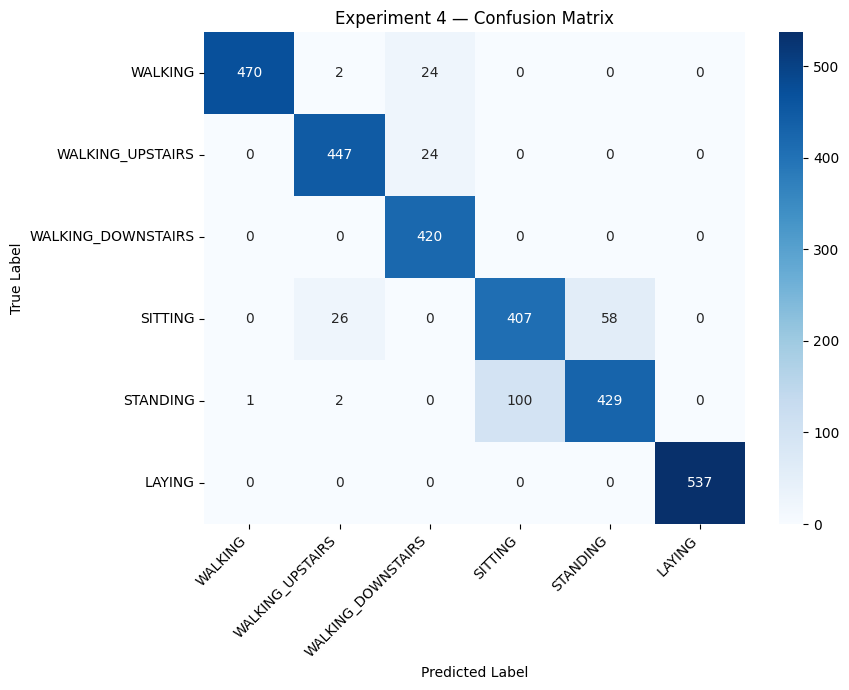

{'experiment': 'Experiment 4 - Autoencoder + CNN + GRU (Main Hybrid)', 'model': 'Encoder(frozen) + Conv1D + GRU + Dense', 'input_shape': [128, 9], 'num_classes': 6, 'optimizer': 'Adam', 'learning_rate': 0.001, 'batch_size': 64, 'gru_units': 64, 'epochs_trained': 33, 'test_loss': 0.3790930211544037, 'test_accuracy': 0.9195792078971863, 'total_parameters': 117638}


In [37]:
test_loss4, test_acc4 = model_exp4.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc4:.4f}")
print(f"Test Loss:     {test_loss4:.4f}")

y_pred4 = np.argmax(model_exp4.predict(X_test), axis=1)
target_names = [activity_labels[str(i)] for i in range(NUM_CLASSES)]

report4 = classification_report(y_test, y_pred4, target_names=target_names, digits=4)
print(report4)

with open(os.path.join(RESULTS_DIR, "exp4_classification_report.txt"), "w") as f:
    f.write(report4)

# Confusion matrix
cm4 = confusion_matrix(y_test, y_pred4)
plt.figure(figsize=(9, 7))
sns.heatmap(cm4, annot=True, fmt="d", xticklabels=target_names,
            yticklabels=target_names, cmap="Blues")
plt.title('Experiment 4 — Confusion Matrix')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "exp4_confusion_matrix.png"), dpi=300, bbox_inches="tight")
plt.show()

# Model kaydet
model_exp4.save(os.path.join(MODELS_DIR, "exp4_final.keras"))

# JSON kaydet
results4 = {
    "experiment": "Experiment 4 - Autoencoder + CNN + GRU (Main Hybrid)",
    "model": "Encoder(frozen) + Conv1D + GRU + Dense",
    "input_shape": list(INPUT_SHAPE),
    "num_classes": NUM_CLASSES,
    "optimizer": "Adam",
    "learning_rate": 0.001,
    "batch_size": 64,
    "gru_units": 64,
    "epochs_trained": len(history_exp4.history["loss"]),
    "test_loss": float(test_loss4),
    "test_accuracy": float(test_acc4),
    "total_parameters": model_exp4.count_params()
}
with open(os.path.join(RESULTS_DIR, "exp4_results.json"), "w") as f:
    json.dump(results4, f, indent=4)

print(results4)